# Game of Life Mosaics

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cellpylib as cpl

The original pattern that does not change over time is called a "pond". This will be basis of the edges for all still life mosaics. It takes the following shape:

(-0.5, 3.5, 3.5, -0.5)

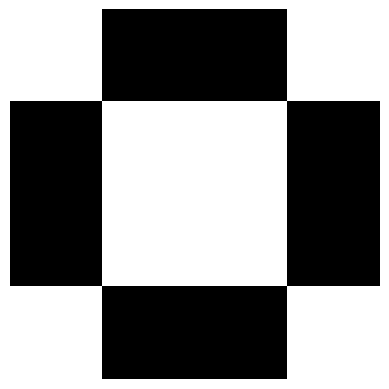

In [3]:
pond_pattern = np.array([
    [0, 1, 1, 0],
    [1, 0, 0, 1],
    [1, 0, 0, 1],
    [0, 1, 1, 0]])

plt.imshow(pond_pattern, cmap='Greys')
plt.axis('off')

These can be concatenated together in order to create large plains of still lives.

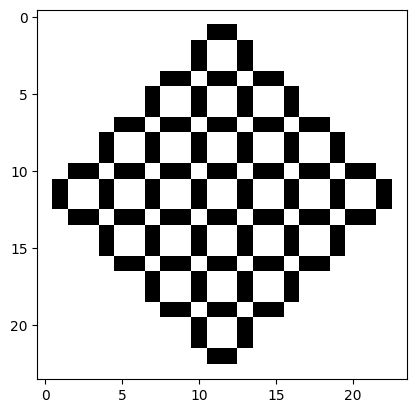

In [4]:
pond_width = 6
pattern_level = 4
width = pond_width * pattern_level

# create a double pattern by stacking the original pattern
if pattern_level > 1:
    pond_pattern_multiple = np.vstack((np.vstack([pond_pattern[:-1]]*(pattern_level-1)),
                                    pond_pattern,
                                    np.vstack([pond_pattern[1:]]*(pattern_level-1))))
    pond_pattern_multiple = np.hstack((np.hstack([pond_pattern_multiple[:,:-1]]*(pattern_level-1)),
                                    pond_pattern_multiple,
                                    np.hstack([pond_pattern_multiple[:,1:]]*(pattern_level-1))))
else:
    pond_pattern_multiple = pond_pattern.copy()
# add a edge to the pattern
pond_pattern_multiple = np.pad(pond_pattern_multiple, pad_width=1, constant_values=0)

### mask all the corners
# diagonal corners
mask_even = np.array([[(i+j)<pond_width*pattern_level/2 for j in range(width)] for i in range(width)])
mask_even = mask_even + mask_even[::-1, ::-1]

# off-diagonal corners
mask_odd = np.array([[(i-j)>=pond_width*pattern_level/2 for j in range(width)] for i in range(width)])
mask_odd = mask_odd + mask_odd.T

mask = mask_even + mask_odd
pond_pattern_multiple = np.where( 1- mask, pond_pattern_multiple, 0)

# # show the pattern
plt.imshow(pond_pattern_multiple, cmap='Greys')

The interior of this diamond-shaped Still Life may be removed as well

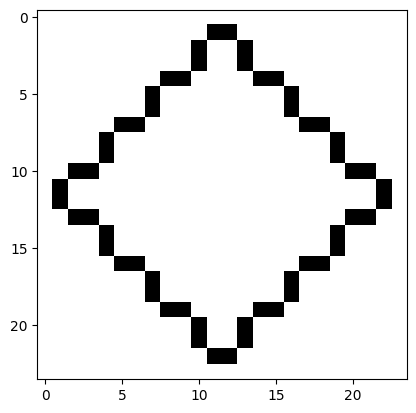

In [5]:
### mask the interior
mask_corner = np.array([[(i+j)<pond_width*pattern_level/2+3 for j in range(width)] for i in range(width)])
mask = mask_corner + mask_corner[::-1, ::-1] + mask_corner[::-1] + mask_corner[:, ::-1]

pond_pattern_edge = np.where(mask, pond_pattern_multiple, 0)

# # show the pattern
plt.imshow(pond_pattern_edge, cmap='Greys')

### Glue the mosaic tiles together

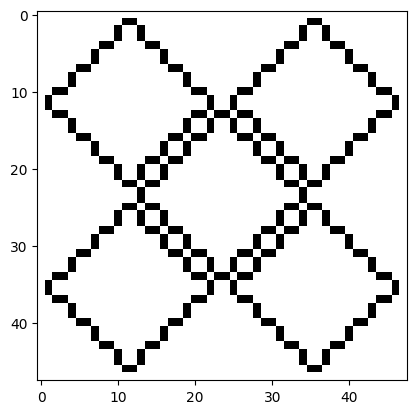

In [6]:
N_odd_tiles = 1

# add odd tiles
empty_mosaic_odd = np.hstack([pond_pattern_edge]*N_odd_tiles)
empty_mosaic_odd = np.vstack([empty_mosaic_odd]*N_odd_tiles)
# add white edge around odd tiles
pad_width = ( (pond_width-3)*(2*pattern_level-1) + 1 + 2 ) // 2
empty_mosaic_odd = np.pad(empty_mosaic_odd, pad_width=pad_width, constant_values=0)

# add even tiles
empty_mosaic_even = np.hstack([pond_pattern_edge]*(N_odd_tiles+1))
empty_mosaic_even = np.vstack([empty_mosaic_even]*(N_odd_tiles+1))

# add even tiles to odd tiles
empty_mosaic = empty_mosaic_odd + empty_mosaic_even

plt.imshow(empty_mosaic, cmap='Greys')

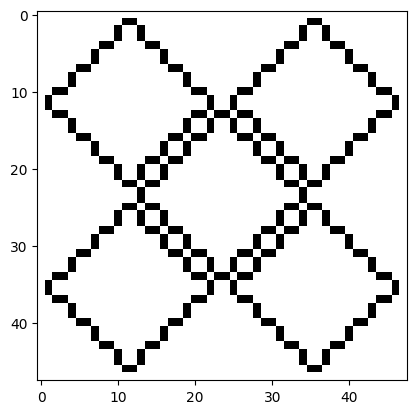

In [7]:
### check whether the pattern is indeed static under the Game of Life rules

# Run the Game of Life for 1 additional time step
game_of_life_empty_mosaic = cpl.evolve2d(
    empty_mosaic[np.newaxis,:,:],
    timesteps=2,
    neighbourhood='Moore',
    apply_rule=cpl.game_of_life_rule
)

# Plot the next time step, which should be identical to the original pattern
plt.imshow(game_of_life_empty_mosaic[-1], cmap='Greys')

# All symmetric patterns that can fill up the tile

First we again make an empty tile with the function `empty_tile`

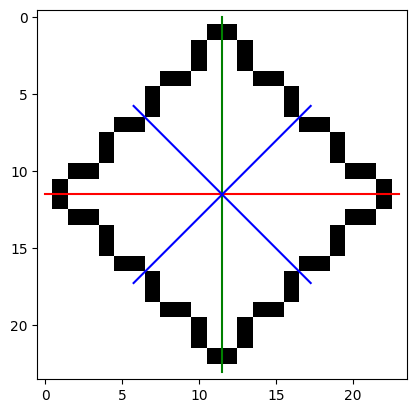

In [8]:
def empty_tile(pattern_level=3):
    pond_pattern = np.array([
        [0, 1, 1, 0],
        [1, 0, 0, 1],
        [1, 0, 0, 1],
        [0, 1, 1, 0]])
    pond_width = 6
    width = pond_width * pattern_level

    # create a double pattern by stacking the original pattern
    if pattern_level > 1:
        pond_pattern_multiple = np.vstack((np.vstack([pond_pattern[:-1]]*(pattern_level-1)),
                                        pond_pattern,
                                        np.vstack([pond_pattern[1:]]*(pattern_level-1))))
        pond_pattern_multiple = np.hstack((np.hstack([pond_pattern_multiple[:,:-1]]*(pattern_level-1)),
                                        pond_pattern_multiple,
                                        np.hstack([pond_pattern_multiple[:,1:]]*(pattern_level-1))))
    else:
        pond_pattern_multiple = pond_pattern.copy()
        
    # add a edge to the pattern
    pond_pattern_multiple = np.pad(pond_pattern_multiple, pad_width=1, constant_values=0)

    ### mask all the corners
    # diagonal corners
    mask_corner = np.array([[(i+j)<pond_width*pattern_level/2 for j in range(width)] for i in range(width)])
    mask = mask_corner + mask_corner[::-1, ::-1] + mask_corner[::-1] + mask_corner[:, ::-1]

    pond_pattern_multiple = np.where(1 - mask, pond_pattern_multiple, 0)

    ### mask the interior
    mask_larger_corner = np.array([[(i+j)<pond_width*pattern_level/2+3 for j in range(width)] for i in range(width)])
    mask = mask_larger_corner + mask_larger_corner[::-1, ::-1] + mask_larger_corner[::-1] + mask_larger_corner[:, ::-1]

    pond_pattern_edge = np.where(mask, pond_pattern_multiple, 0)

    return pond_pattern_edge

tile = empty_tile(pattern_level=4)
plt.imshow(tile, cmap='Greys')

# symmetry lines
plt.plot([0, 23], [11.5, 11.5], color='red')
plt.plot([11.5, 11.5], [0, 23], color='green')
plt.plot([23/4, 3*23/4], [23/4, 3*23/4], color='blue')
plt.plot([3*23/4, 23/4], [23/4, 3*23/4], color='blue')

In this tile we want to create a pattern that exhibits the following properties:
1. It remains static over time when applying the Game of Life rules
2. It is vertically symmetric (red line)
3. It is horizontally symmetric (green line)
4. It is diagonally symmetric (blue lines)

The latter rules imply that
- $f(x,y) = f(x,-y)$
- $f(x,y) = f(-x,y)$
- $f(x,y) = f(y,x)$

where $x$ and $y$ denote the position compared to the centre of the pattern, and function $f$ maps this position to a colour (black or white).

In practice, this means that we will look for a colour fill of a single 'slice' of the pattern. This slice needs to be filled up in such a way that the resulting pattern stays static.

Number of free tiles: 27


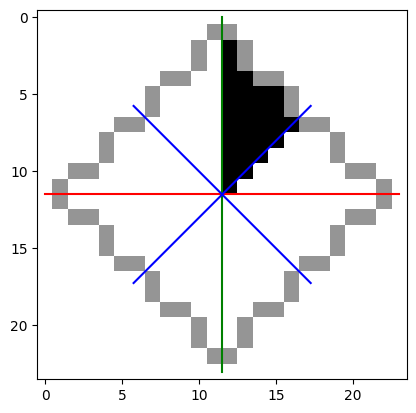

In [9]:
# hard-coded for pattern_level=4

tile = empty_tile(pattern_level=4)
height, width = tile.shape

# first column
tile[2:height//2, width//2] = 2
# second column
tile[4:height//2-1, width//2+1] = 2
# third column
tile[5:height//2-2, width//2+2] = 2
# fourth column
tile[5:height//2-3, width//2+3] = 2
# fifth column
tile[7,width//2+4] = 2

plt.imshow(tile, cmap='Greys')

# symmetry lines
plt.plot([0, 23], [11.5, 11.5], color='red')
plt.plot([11.5, 11.5], [0, 23], color='green')
plt.plot([23/4, 3*23/4], [23/4, 3*23/4], color='blue')
plt.plot([3*23/4, 23/4], [23/4, 3*23/4], color='blue')

# number of free tiles
N_free_tiles = np.sum(tile == 2)
print(f"Number of free tiles: {N_free_tiles}")

Following the discussion in the Opt Art book, we may consider that every cell in a Still Life is in exactly one of three states
1. Dead with fewer than $3$ living neighbours, denoted $L_{i,j}$ ("low dead")
2. Dead with more than $3$ living neighbours, denoted $H_{i,j}$ ("high dead")
3. Alive with either $2$ or $3$ living neighbours, denoted $A_{i,j}$ ("alive")

The Still Life demands boil down to ...
1. $4L_{i,j} + \mathcal{N}(A_{i,j}) \leq 6$, the _low-dead constraint_
2. $4H_{i,j} \leq \mathcal{N}(A_{i,j})$, the _high-dead constraint_
3. $2A_{i,j} \leq \mathcal{N}(A_{i,j})$ and $3A_{i,j} + \mathcal{N}(c_{i,j}) \leq 6$, the _staying-alive constraints_
4. $L_{i,j} + H_{i,j} + A_{i,j} = 1$, the _precisely-one-of-these-must-happen constraint_

Here $\mathcal{N}$ denotes the _sum_ of all Alive states $A_{i,j}$ i the neighbourhood of the node with index $(i,j)$. The additional symmetry constraints are
1. $s_{i,j} = s_{w-1-i, j}$, _vertical symmetry_ (mirrored over horizontal mirror)
2. $s_{i,j} = s_{i, w-1-j}$, _horizontal symmetry_ (mirrored over vertical mirror)
3. $s_{i,j} = s_{j,i}$, _diagonal symmetry_ (mirrored over the second bisector)

with $s \in \{L, H, A\}$. Combinations of these symmetry operations generate the fourth symmetry, over the first bisector.

In practice, if we have a cell $c_{i,j}$ with value $s_{i,j}$ in the slither highlighted above, we can find the other values
1. $s_{w-1-i, j}$ from vertical symmetry
2. $s_{i, w-1-j}$ from horizontal symmetry
3. $s_{w-1-i, w-1-j}$ from vertical and horizontal symmetry
4. $s_{j,i}$ from diagonal symmetry
5. $s_{j, w-1-i}$ from diagonal and vertical symmetry
6. $s_{w-1-j, i}$ from diagonal and horizontal symmetry
7. $s_{w-1-j, w-1-i}$ from diagonal, horizontal, and vertical symmetry

Number of free tiles: 8


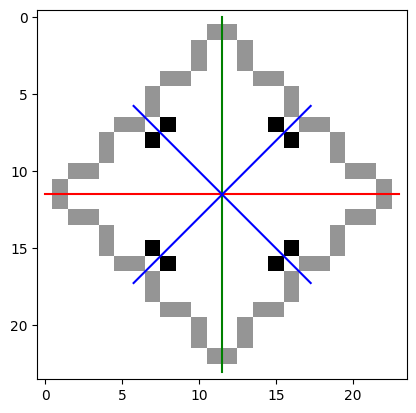

In [10]:
# hard-coded for pattern_level=4
pattern_level = 4
tile = empty_tile(pattern_level=pattern_level)
height, width = tile.shape

# test value
(i,j) = 8,16
tile[i,j] = 2

# add all symmetries
tile[width-i-1, j] = 2  # vertical symmetry
tile[i, width-j-1] = 2  # horizontal symmetry
tile[width-i-1, width-j-1] = 2  # vertical and horizontal symmetry
tile[j, i] = 2  # diagonal symmetry
tile[j, width-1-i] = 2 # diagonal and vertical symmetry
tile[width-1-j, i] = 2  # diagonal and horizontal symmetry
tile[width-1-j, width-1-i] = 2  # all symmetries

plt.imshow(tile, cmap='Greys')

# symmetry lines
width = pattern_level * pond_width-1
plt.plot([0, width], [width/2, width/2], color='red')
plt.plot([width/2, width/2], [0, width], color='green')
plt.plot([width/4, 3*width/4], [width/4, 3*width/4], color='blue')
plt.plot([3*width/4, width/4], [width/4, 3*width/4], color='blue')

# number of free tiles
N_free_tiles = np.sum(tile == 2)
print(f"Number of free tiles: {N_free_tiles}")

In [11]:
from gurobipy import Model, GRB, quicksum
from scipy.ndimage import binary_fill_holes

# Grid size
pattern_level = 4
tile = empty_tile(pattern_level=pattern_level)
n = tile.shape[0]

# make mask for cells that are outside the tile pattern
tile = (tile > 0).astype(np.uint8)
# Fill the interior
outside_tile = 1-binary_fill_holes(tile).astype(np.uint8)

# Create model
model = Model("still_life")

# Decision variables
A = {}  # Alive
L = {}  # Low dead
H = {}  # High dead

for i in range(n):
    for j in range(n):
        A[i, j] = model.addVar(vtype=GRB.BINARY, name=f"A_{i}_{j}")
        L[i, j] = model.addVar(vtype=GRB.BINARY, name=f"L_{i}_{j}")
        H[i, j] = model.addVar(vtype=GRB.BINARY, name=f"H_{i}_{j}")

model.update()

# Define neighbors function
def neighbors(i, j, n):
    return [
        ((i + di) % n, (j + dj) % n)
        for di in [-1, 0, 1]
        for dj in [-1, 0, 1]
        if not (di == 0 and dj == 0)
    ]

def symmetric_coords(i, j, n):
    return {
        "ver": (n - 1 - i, j),
        "hor": (i, n - 1 - j),
        "ver_and_hor": (n - 1 - i, n - 1 - j),
        "diag": (j, i),
        "diag_and_ver": (j, n - 1 - i),
        "diag_and_hor": (n - 1 - j, i),
        "all_sym": (n - 1 - j, n - 1 - i)
    }

# TODO: this is hard-coded for pattern_level=4
dead_edges = {
    "level_4" : [
        (2,11),
        (3,11),
        (5,14),
        (5,15),
        (6,15)],
    "level_5" : [
        (2,15),
        (3,15),
        (5,17),
        (5,18),
        (6,18),
        (8,20),
        (8,21)]
}

# Constraints
for i in range(n):
    for j in range(n):
        N = neighbors(i, j, n)
        neighbor_sum = quicksum(A[ii, jj] for (ii, jj) in N)

        # Low-dead
        model.addConstr(4 * L[i, j] + neighbor_sum <= 6, name=f"low_dead_{i}_{j}")

        # High-dead
        model.addConstr(4 * H[i, j] <= neighbor_sum, name=f"high_dead_{i}_{j}")

        # Stayin' alive constraints
        model.addConstr(2 * A[i, j] <= neighbor_sum, name=f"stay1_{i}_{j}")
        model.addConstr(3 * A[i, j] + neighbor_sum <= 6, name=f"stay2_{i}_{j}")

        # Exactly one of L, H, or A is true
        model.addConstr(L[i, j] + H[i, j] + A[i, j] == 1, name=f"oneof_{i}_{j}")

        # Symmetry constraints
        sym_coords = symmetric_coords(i, j, n)
        for (ii, jj) in sym_coords.values():
            model.addConstr(A[i, j] == A[ii, jj])
            model.addConstr(L[i, j] == L[ii, jj])
            model.addConstr(H[i, j] == H[ii, jj])

        # Constraint to ensure that some values are alive along the tile pattern
        if tile[i,j]:
            model.addConstr(A[i, j] == int(tile[i,j]), name=f"force_alive_{i}_{j}")
        # Constraint to ensure that cells outside the tile pattern are dead
        if outside_tile[i, j]:
            model.addConstr(A[i, j] == 0, name=f"force_dead_{i}_{j}")

        if pattern_level == 5:
            # Constraint to ensure that cells on the edges are dead
            if (i, j) in dead_edges["level_5"]:
                model.addConstr(A[i, j] == 0, name=f"force_dead_edge_{i}_{j}")
        elif pattern_level == 4:
            # Constraint to ensure that cells on the edges are dead
            if (i, j) in dead_edges["level_4"]:
                model.addConstr(A[i, j] == 0, name=f"force_dead_edge_{i}_{j}")

# Objective: maximize number of living cells
model.setObjective(quicksum(A[i, j] for i in range(n) for j in range(n)), GRB.MAXIMIZE)

# === Iterative exclusion ===
solutions = []
iterator = 0
solution_limit = 500

# I find 352 solutions for pattern_level=4
while True:
    # Solve
    model.optimize()

    if model.status != GRB.OPTIMAL:
        print("No more optimal solutions found.")
        break

    # Extract current solution
    sol = np.array([[round(A[i, j].X) for j in range(n)] for i in range(n)])
    solutions.append(sol)

    # Identify which cells are alive
    alive_cells = [(i, j) for i in range(n) for j in range(n) if round(A[i, j].X) == 1]

    # Add exclusion constraint: prevent rediscovery of this exact solution
    model.addConstr(
        quicksum(1 - A[i, j] for (i, j) in alive_cells) +
        quicksum(A[i, j] for i in range(n) for j in range(n) if (i, j) not in alive_cells)
        >= 1,
        name=f"exclude_solution_{len(solutions)}"
    )

    if len(solutions) >= solution_limit:
        print("Reached solution limit.")
        break

solutions = np.array(solutions)

# # change output to numpy arrays for easier visualization
# A_array = np.fromfunction(lambda i, j: np.vectorize(lambda x, y: round(A[int(x), int(y)].X))(i, j), (n, n), dtype=int)
# L_array = np.fromfunction(lambda i, j: np.vectorize(lambda x, y: round(L[int(x), int(y)].X))(i, j), (n, n), dtype=int)
# H_array = np.fromfunction(lambda i, j: np.vectorize(lambda x, y: round(H[int(x), int(y)].X))(i, j), (n, n), dtype=int)


Set parameter Username
Set parameter LicenseID to value 2674336
Academic license - for non-commercial use only - expires 2026-06-02
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-9850H CPU @ 2.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 15361 rows, 1728 columns and 46753 nonzeros
Model fingerprint: 0x45fc1bca
Variable types: 0 continuous, 1728 integer (1728 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 6e+00]
Presolve removed 15270 rows and 1673 columns
Presolve time: 0.04s
Presolved: 91 rows, 55 columns, 518 nonzeros
Variable types: 0 continuous, 55 integer (55 binary)
Found heuristic solution: objective 60.0000000
Found heuristic solution: objective 124.0000000

Root relaxation: objective 1.375826e+02, 57 iter

In [12]:
SAVEDATA=False

if SAVEDATA:
    np.save(f"solutions_pattern_level_{pattern_level}.npy", solutions)
else:
    solutions = np.load(f"solutions_pattern_level_{pattern_level}.npy")

print(f"Number of unique densities: {np.unique(np.sum(solutions, axis=(1, 2))).size}")
pixel_sums, counts = np.unique(np.sum(solutions, axis=(1, 2)), return_counts=True)
print(pixel_sums)
print(counts)

Number of unique densities: 19
[ 56  60  64  72  76  80  84  88  92  96 100 104 108 112 116 120 124 128
 132]
[ 1  1  1  5  3  8  4  9  3 10  5  2  3  5  5  7  5  6  2]


In [13]:
# Linearly map pixel_sums to values from 0 to 255
pixel_sums_normalized = 255 * (pixel_sums - pixel_sums.min()) / (pixel_sums.max() - pixel_sums.min())
pixel_sums_mapped = pixel_sums_normalized.astype(np.uint8)
print(pixel_sums_mapped)

[  0  13  26  53  67  80  93 107 120 134 147 161 174 187 201 214 228 241
 255]


In [314]:
pixel_sums_mapped[0:-1] + (pixel_sums_mapped[1:] - pixel_sums_mapped[:-1])/2

array([  6.5,  19.5,  39.5,  60. ,  73.5,  86.5, 100. , 113.5, 127. ,
       140.5, 154. , 167.5, 180.5, 194. , 207.5, 221. , 234.5, 248. ])

That means that ... 
- Greyscale values from $0$ to $6$ are mapped to the tile with pixel sum $56$
- Greyscale values from $7$ to $20$ are mapped to the tile with pixel sum $60$
- Greyscale values from $21$ to ...

True


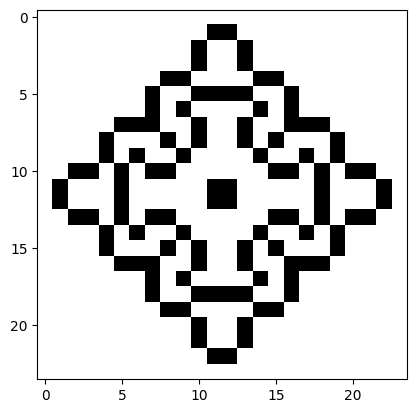

In [17]:
### check whether the pattern is indeed static under the Game of Life rules

solution = solutions[np.random.randint(len(solutions))]

# Run the Game of Life for 1 additional time step
game_of_life_evol = cpl.evolve2d(
    solution[np.newaxis,:,:],
    timesteps=2,
    neighbourhood='Moore',
    apply_rule=cpl.game_of_life_rule
)

print((game_of_life_evol[0] == game_of_life_evol[1]).all())

plt.imshow(solution, cmap='Greys')

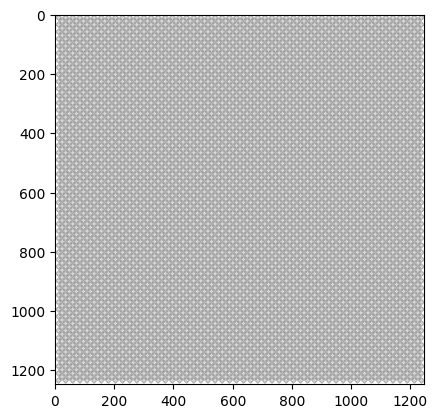

In [30]:
N_odd_tiles = 51

# add odd tiles
solution_mosaic_odd = np.hstack([solution]*N_odd_tiles)
solution_mosaic_odd = np.vstack([solution_mosaic_odd]*N_odd_tiles)
# add white edge around odd tiles
pad_width = ( (pond_width-3)*(2*pattern_level-1) + 1 + 2 ) // 2
solution_mosaic_odd = np.pad(solution_mosaic_odd, pad_width=pad_width, constant_values=0)

# add even tiles
solution_mosaic_even = np.hstack([solution]*(N_odd_tiles+1))
solution_mosaic_even = np.vstack([solution_mosaic_even]*(N_odd_tiles+1))

# add even tiles to odd tiles
solution_mosaic = solution_mosaic_odd + solution_mosaic_even

### check whether the pattern is indeed static under the Game of Life rules

# Run the Game of Life for 1 additional time step\
# timesteps = 2
# game_of_life_solution_mosaic = cpl.evolve2d(
#     solution_mosaic[np.newaxis,:,:],
#     timesteps=timesteps,
#     neighbourhood='Moore',
#     apply_rule=cpl.game_of_life_rule
# )

# print((game_of_life_solution_mosaic[0]==game_of_life_solution_mosaic[1]).all())

# Plot the next time step, which should be identical to the original pattern
# plt.imshow(game_of_life_solution_mosaic[-1], cmap='Greys')
plt.imshow(solution_mosaic, cmap='Greys')

In [31]:
# add little glider
glider = np.array([[0, 1, 0],
                   [0, 0, 1],
                   [1, 1, 1]])

solution_mosaic[2:5,1:4] = glider

def numpy_to_cells(array, filename="output.cells"):
    """
    Function that saves a NumPy array to a .cells file format that can be used in Golly
    """
    with open(filename, 'w') as f:
        f.write('!Generated from NumPy array\n')
        for row in array:
            line = ''.join('O' if cell else '.' for cell in row)
            f.write(line + '\n')

# Example usage:
numpy_to_cells(solution_mosaic, filename=f"test.cells")

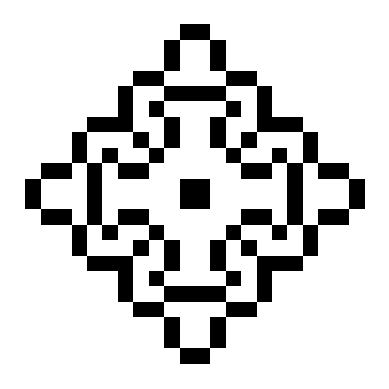

In [19]:
# Pad the solution with zeros to simulate null boundary conditions
pad = 1  # or more if you want a thicker boundary
padded_solution = np.pad(solution, pad_width=pad, mode='constant', constant_values=0)

# Run the Game of Life for 1 additional time step
game_of_life_null_bc = cpl.evolve2d(
    padded_solution[np.newaxis, :, :],
    timesteps=2,
    neighbourhood='Moore',
    apply_rule=cpl.game_of_life_rule
)

# Remove the padding for visualization if you want to compare with the original
result = game_of_life_null_bc[-1][pad:-pad, pad:-pad]

# Plot the next time step, which should be identical to the original pattern if still life
plt.imshow(result, cmap='Greys')
plt.axis('off')
plt.show()

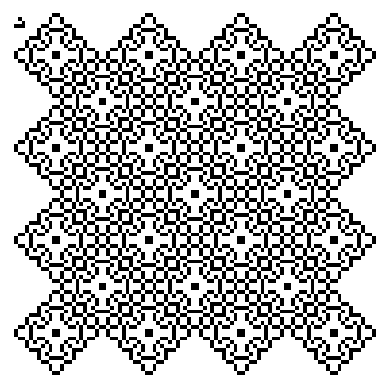

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# add little glider
glider = np.array([[0, 1, 0],
                   [0, 0, 1],
                   [1, 1, 1]])

solution_mosaic[2:5,1:4] = glider

# Run the Game of Life for 1 additional time step\
timesteps = 100
game_of_life_solution_mosaic = cpl.evolve2d(
    solution_mosaic[np.newaxis,:,:],
    timesteps=timesteps,
    neighbourhood='Moore',
    apply_rule=cpl.game_of_life_rule
)

fig, ax = plt.subplots()
img = ax.imshow(game_of_life_solution_mosaic[0], cmap='Greys')
ax.axis('off')  # Optional: hides the axis for a cleaner look

def update(frame):
    img.set_data(game_of_life_solution_mosaic[frame])
    return [img]

ani = FuncAnimation(fig, update, frames=game_of_life_solution_mosaic.shape[0], interval=200, blit=True)

# To display the animation in the notebook
HTML(ani.to_jshtml())


# Make greyscale image

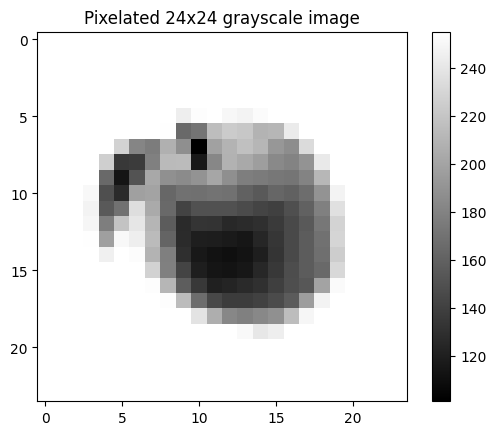

In [318]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def process_image(path, grid_size):
    """
    1. Load image as grayscale
    2. Rotate 45 degrees
    3. Pixelate by averaging over blocks
    4. Return low-res numpy array
    """
    # 1. Load image in grayscale
    img = Image.open(path).convert('L')

    # 2. Rotate 45 degrees with expand so nothing is cut off
    img = img.rotate(45, expand=True, fillcolor=255)

    # Convert to numpy
    arr = np.array(img)

    # 3. Compute block size (grid cell size)
    h, w = arr.shape
    cell_h = h // grid_size
    cell_w = w // grid_size

    # 4. Pixelate: mean of each cell
    lowres = np.zeros((grid_size, grid_size))

    for i in range(grid_size):
        for j in range(grid_size):
            block = arr[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            lowres[i, j] = np.mean(block)

    return lowres

# === Example usage ===
lowres_array = process_image("orange.jpg", grid_size=24)

# Display
plt.imshow(lowres_array, cmap='gray')
plt.title("Pixelated 24x24 grayscale image")
plt.colorbar()
plt.show()


Now we will split this image into two pixel subsets: the set of indices whose sum is even, en the set of indices whose sum is odd. The corresponding pixel values are mapped to Still Life tiles. These are added together (after a 45 degree rotation) and make up the complete Still Life.

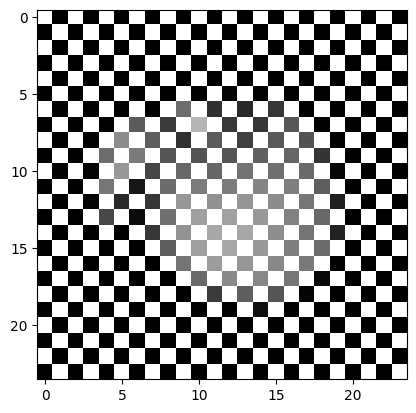

In [ ]:
mask_even = np.fromfunction(lambda i, j: (i + j) % 2 == 0, lowres_array.shape, dtype=int)
mask_odd = np.fromfunction(lambda i, j: (i + j) % 2 == 1, lowres_array.shape, dtype=int)
lowres_even = np.where(mask_even, lowres_array, -1)
lowres_odd = np.where(mask_odd, lowres_array, -1)

plt.imshow(lowres_odd, cmap='Greys')

lowres_odd_rotated = np.empty((lowres_odd.shape[0]//2,lowres_odd.shape[0]//2))
for i in range(lowres_odd.shape[0]//2):
    for j in range(lowres_odd.shape[0]//2):
        lowres_odd_rotated[i,j] = lowres_odd[12-i, j]

array([[255.        ,  -1.        , 255.        ,  -1.        ,
        155.32313609,  -1.        , 234.9639645 ,  -1.        ,
        165.09426036,  -1.        , 150.51189349,  -1.        ],
       [ -1.        , 255.        ,  -1.        , 250.66171598,
         -1.        , 126.93094675,  -1.        , 199.22863905,
         -1.        , 169.69733728,  -1.        , 170.2904142 ],
       [255.        ,  -1.        , 255.        ,  -1.        ,
        164.96331361,  -1.        , 151.32775148,  -1.        ,
        187.74721893,  -1.        , 189.81467456,  -1.        ],
       [ -1.        , 255.        ,  -1.        , 255.        ,
         -1.        , 135.59514793,  -1.        , 178.05976331,
         -1.        , 213.61136095,  -1.        , 182.46230769],
       [255.        ,  -1.        , 255.        ,  -1.        ,
        255.        ,  -1.        , 181.05710059,  -1.        ,
        207.30763314,  -1.        , 101.09627219,  -1.        ],
       [ -1.        , 255.        ,

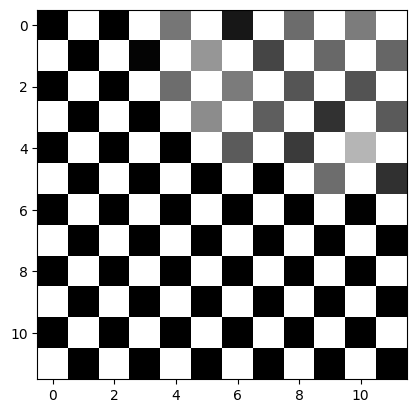

In [ ]:
plt.imshow(lowres_odd_rotated, cmap='Greys')